https://scikit-learn.org/stable/supervised_learning.html#supervised-learning

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder

https://scikit-learn.org/stable/modules/impute.html

https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

https://scikit-learn.org/stable/modules/cross_validation.html


---
# Iris dataset

In [1]:
import sklearn
from sklearn import *
iris = sklearn.datasets.load_iris()


In [2]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, shuffle=True)

In [3]:
from sklearn.neighbors import KNeighborsClassifier

knn_model  = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0 1 1 2 1 2]


In [4]:
y_pred_probs = knn_model.predict_proba(X_test)
print(y_pred_probs)

[[0.         1.         0.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [0.         1.         0.        ]
 [0.         1.         0.        ]
 [1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.         0.         1.        ]
 [0.         0.66666667 0.33333333]
 [0.         1.         0.        ]
 [0.         0.33333333 0.66666667]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.66666667 0.33333333]
 [0.         0.         1.        ]
 [0.         1.         0.        ]
 [0.         1.         0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [0.         0.         1.        ]
 [0.         0.         1.        ]
 [0.         0.         1.        ]
 [0.         0.         1.  

In [5]:
knn_model.score(X_test, y_test)

0.98

In [6]:
knn_model2  = KNeighborsClassifier(n_neighbors=3)
knn_model2.fit(X_train, y_train)

y_pred2 = knn_model2.predict(X_train)

knn_model2.score(X_train, y_train)

0.96

In [7]:
from sklearn import metrics 

print(metrics.f1_score(y_test, y_pred, average='micro'))
print(metrics.f1_score(y_test, y_pred, average='macro'))

0.98
0.978494623655914


[[19  0  0]
 [ 0 15  0]
 [ 0  1 15]]


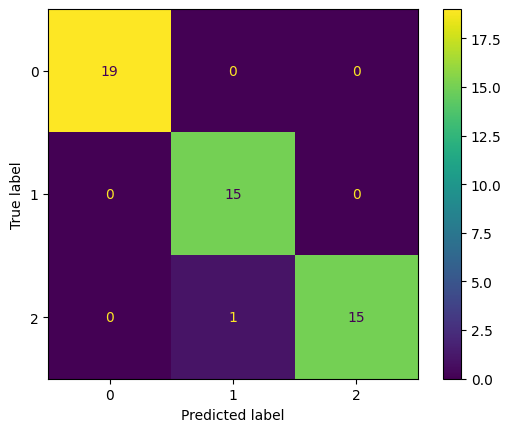

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm , display_labels=knn_model.classes_)
disp.plot()

In [9]:
from sklearn.model_selection import KFold

#kf = KFold(n_splits=10)
#kf.get_n_splits(X)

kf = KFold(n_splits=10, random_state=42, shuffle=True)
#kf.get_n_splits(X)

for train_index, test_index in kf.split(X):
    kf_X_train, kf_X_test = X[train_index], X[test_index]
    kf_y_train, kf_y_test = y[train_index], y[test_index]
    
    knn_model  = KNeighborsClassifier(n_neighbors=3)
    knn_model.fit(kf_X_train, kf_y_train)
    kf_y_pred = knn_model.predict(kf_X_test)
    
    print(knn_model.score(kf_X_test, kf_y_test),  metrics.f1_score(kf_y_test, kf_y_pred, average='micro'), metrics.f1_score(kf_y_test, kf_y_pred, average='macro') )
    
    

1.0 1.0 1.0
1.0 1.0 1.0
1.0 1.0 1.0
0.9333333333333333 0.9333333333333333 0.9373219373219372
1.0 1.0 1.0
0.9333333333333333 0.9333333333333333 0.9220779220779222
0.8666666666666667 0.8666666666666667 0.8412698412698413
1.0 1.0 1.0
1.0 1.0 1.0
0.9333333333333333 0.9333333333333333 0.9487179487179486


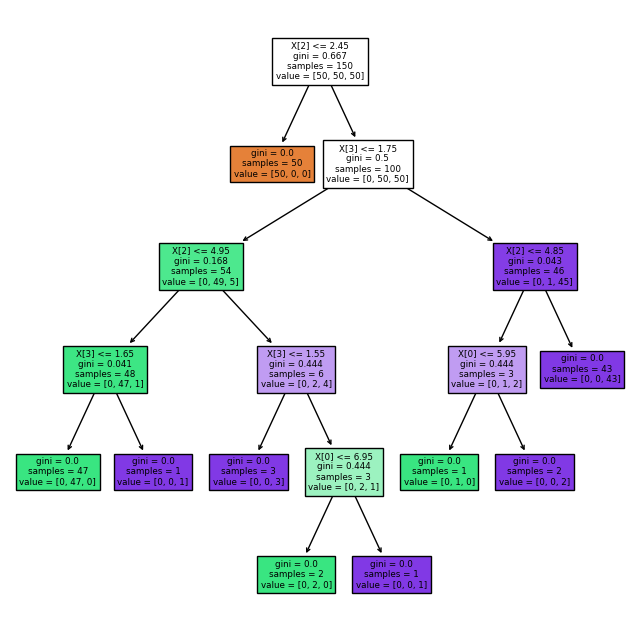

In [10]:
from sklearn import tree 
import matplotlib.pyplot as plt

dtree_model = tree.DecisionTreeClassifier()
dtree_model = dtree_model.fit(X, y)

plt.figure(figsize=(8,8)) 
tree.plot_tree(dtree_model, filled=True)
plt.show()

https://scikit-learn.org/stable/modules/tree.html#

https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

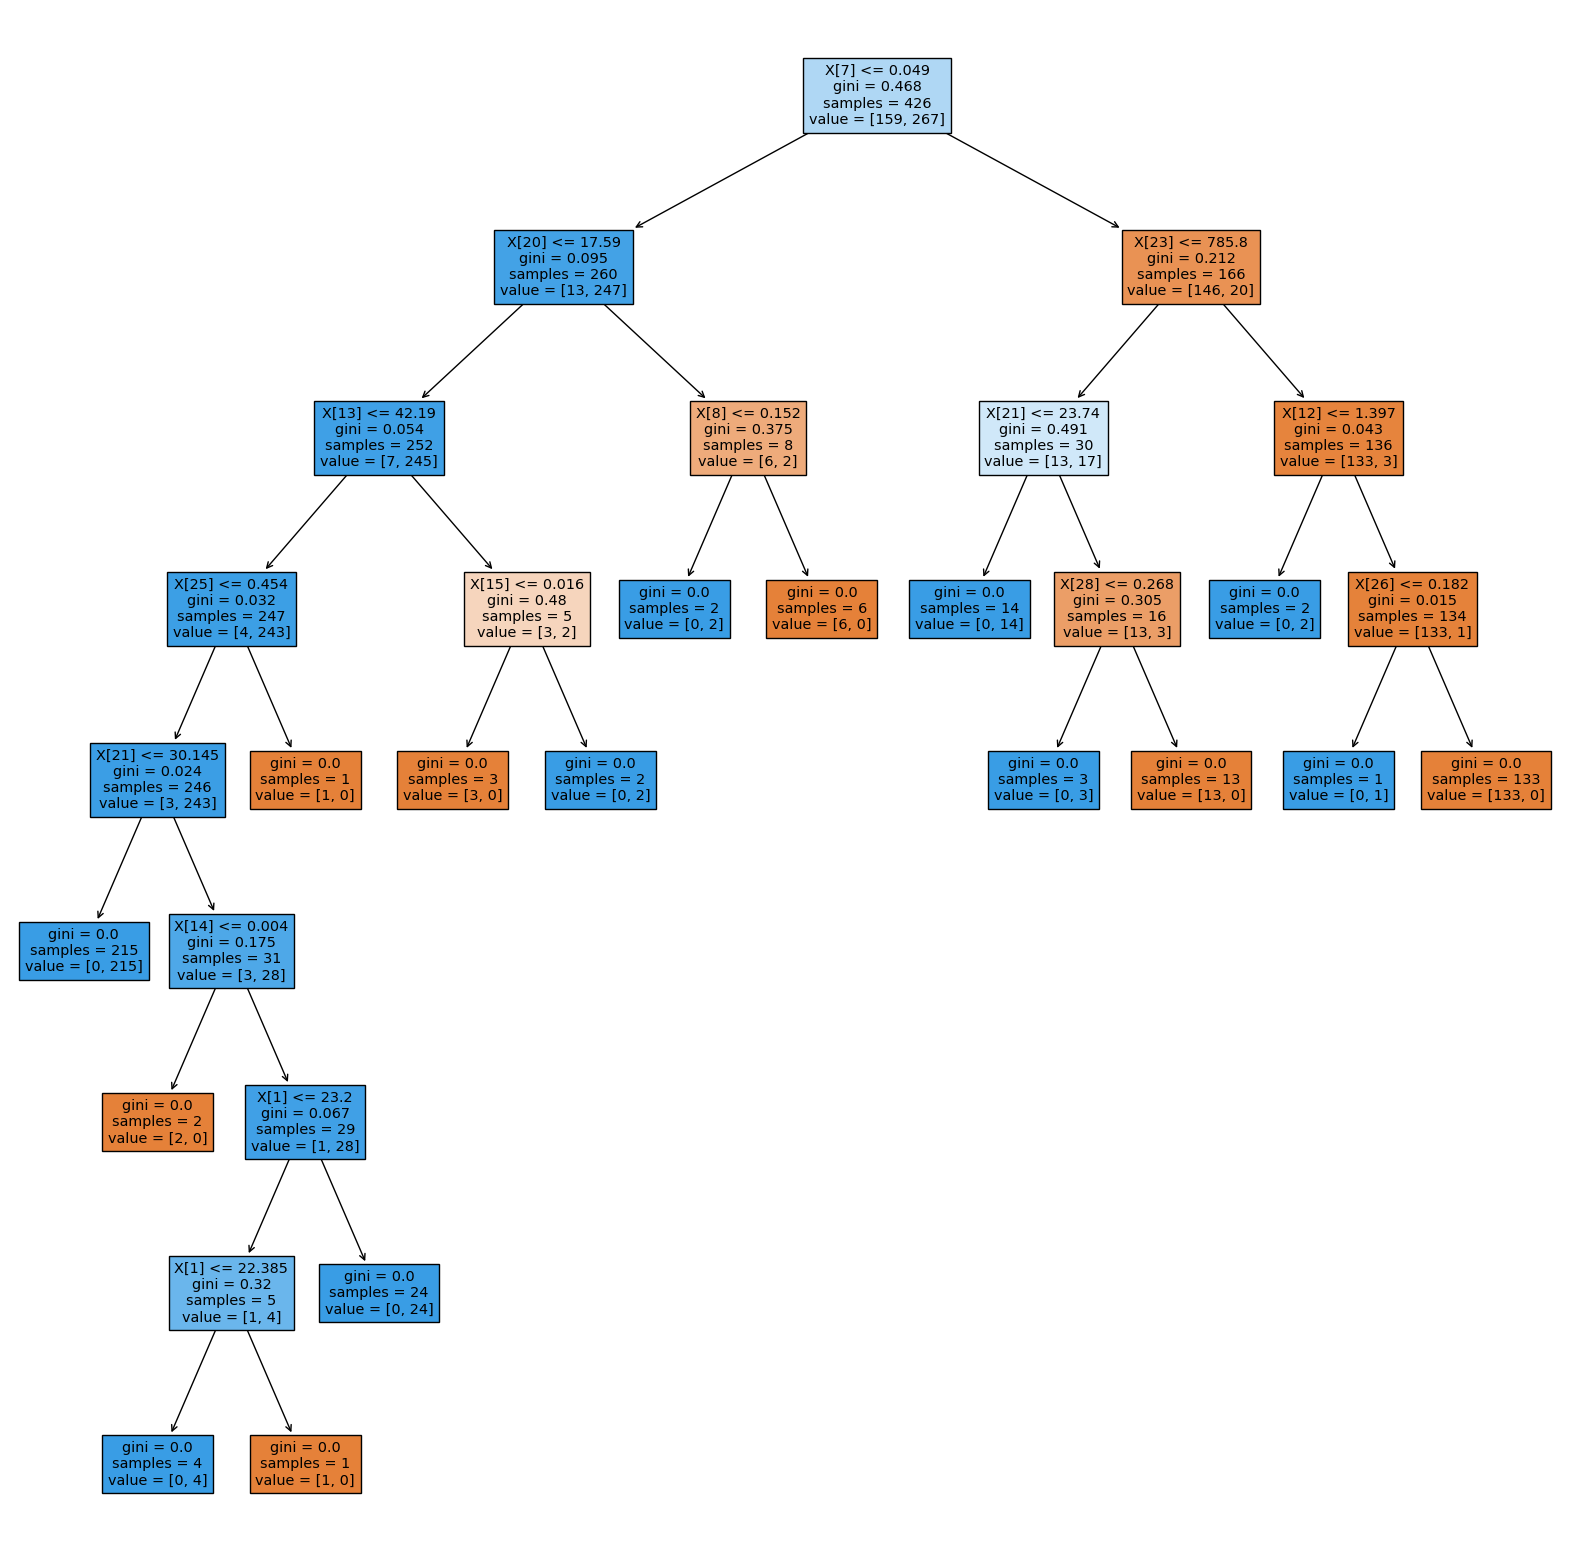

In [11]:
bc = datasets.load_breast_cancer()
X = bc.data
y = bc.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

bc_dtree_model = tree.DecisionTreeClassifier()
bc_dtree_model = dtree_model.fit(X_train, y_train)

plt.figure(figsize=(20,20)) 
tree.plot_tree(dtree_model, filled=True)
plt.show()

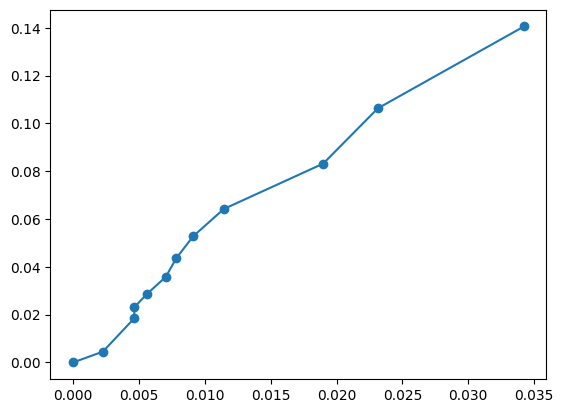

In [12]:
path = bc_dtree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o')

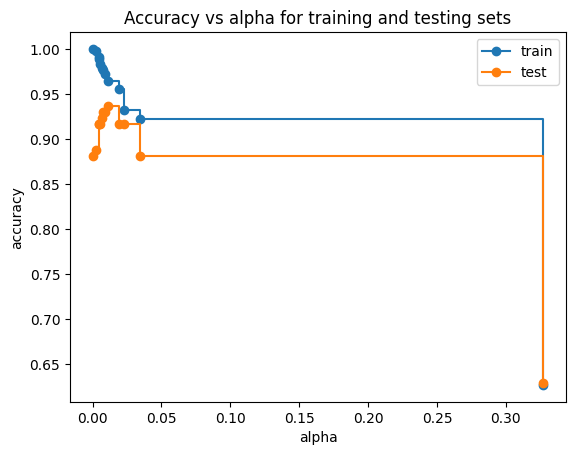

[0.         0.00226647 0.00464743 0.0046598  0.0056338  0.00704225
 0.00784194 0.00911402 0.01144366 0.018988   0.02314163 0.03422475
 0.32729844]


In [13]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
    
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]


fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

print(ccp_alphas)

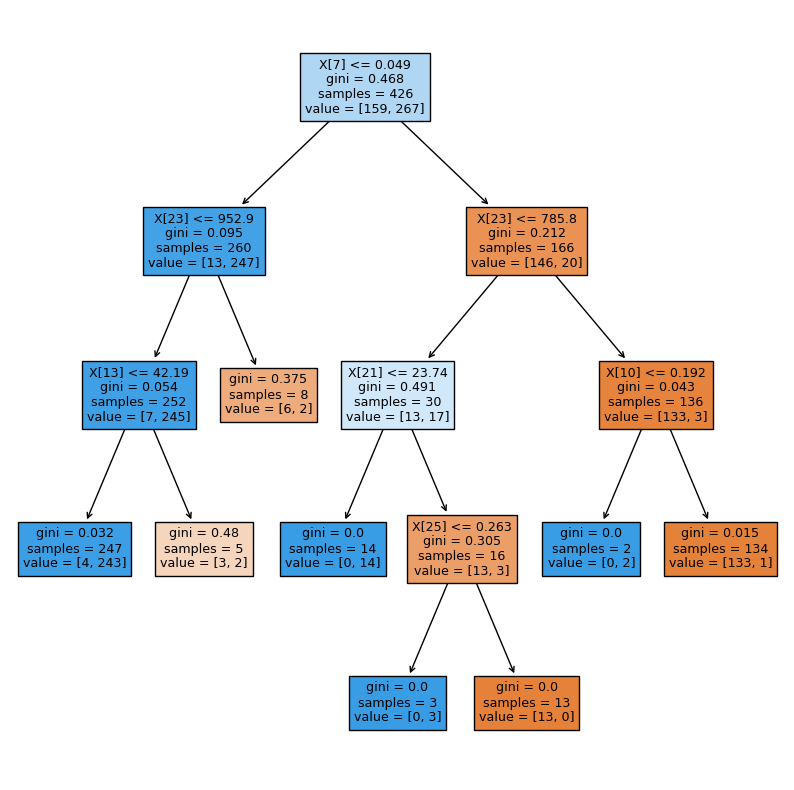

In [14]:
plt.figure(figsize=(10,10)) 
tree.plot_tree(clfs[5], filled=True)
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier


bc = datasets.load_breast_cancer()
X = bc.data
y = bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

rfclf = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=2, random_state=0)

rfclf.fit(X_train, y_train)
y_pred = rfclf.predict(X_test)

print(rfclf.score(X_test, y_test),  metrics.f1_score(y_test, y_pred, average='micro'), metrics.f1_score(y_test, y_pred, average='macro') )

0.951048951048951 0.951048951048951 0.9484684684684684


In [16]:
from sklearn.ensemble import RandomForestClassifier
import statistics 


bc = datasets.load_breast_cancer()
X = bc.data
y = bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


acc_scores = list()
f1macros = list()
f1micros = list()

for i in range(100):
    rfclf = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=2, random_state=i)

    rfclf.fit(X_train, y_train)
    y_pred = rfclf.predict(X_test)

    print(rfclf.score(X_test, y_test),  metrics.f1_score(y_test, y_pred, average='micro'), metrics.f1_score(y_test, y_pred, average='macro') )
    
    acc_scores.append(rfclf.score(X_test, y_test))
    f1macros.append(metrics.f1_score(y_test, y_pred, average='micro'))
    f1micros.append(metrics.f1_score(y_test, y_pred, average='macro'))
    
print('-'*40)
print(min(acc_scores), statistics.mean(acc_scores), max(acc_scores))
print(min(f1macros), statistics.mean(f1macros), max(f1macros))
print(min(f1micros), statistics.mean(f1micros), max(f1micros))

0.951048951048951 0.951048951048951 0.9484684684684684
0.972027972027972 0.972027972027972 0.9702455264253016
0.951048951048951 0.951048951048951 0.9481158969574457
0.9370629370629371 0.9370629370629371 0.9345537757437071
0.951048951048951 0.951048951048951 0.94773664700047
0.9370629370629371 0.9370629370629371 0.9328042604291755
0.9790209790209791 0.9790209790209791 0.9777639558389053
0.965034965034965 0.965034965034965 0.9629399263981755
0.972027972027972 0.972027972027972 0.9702455264253016
0.951048951048951 0.951048951048951 0.9484684684684684
0.9790209790209791 0.9790209790209791 0.9776014201430585
0.972027972027972 0.972027972027972 0.9704545454545455
0.9300699300699301 0.9300699300699301 0.9266215106732347
0.9370629370629371 0.9370629370629371 0.9337451737451739
0.9440559440559441 0.9440559440559441 0.9409090909090909
0.951048951048951 0.951048951048951 0.9484684684684684
0.965034965034965 0.965034965034965 0.9631917631917633
0.958041958041958 0.958041958041958 0.955368289637952

In [17]:
from sklearn.ensemble import RandomForestClassifier
import statistics 


bc = datasets.load_breast_cancer()
X = bc.data
y = bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


acc_scores = list()
f1macros = list()
f1micros = list()

for i in range(100):
    rfclf = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=2, random_state=i, bootstrap=False)

    rfclf.fit(X_train, y_train)
    y_pred = rfclf.predict(X_test)

    print(rfclf.score(X_test, y_test),  metrics.f1_score(y_test, y_pred, average='micro'), metrics.f1_score(y_test, y_pred, average='macro') )
    
    acc_scores.append(rfclf.score(X_test, y_test))
    f1macros.append(metrics.f1_score(y_test, y_pred, average='micro'))
    f1micros.append(metrics.f1_score(y_test, y_pred, average='macro'))
    
print('-'*40)
print(min(acc_scores), statistics.mean(acc_scores), max(acc_scores))
print(min(f1macros), statistics.mean(f1macros), max(f1macros))
print(min(f1micros), statistics.mean(f1micros), max(f1micros))

0.965034965034965 0.965034965034965 0.9629399263981755
0.9370629370629371 0.9370629370629371 0.9337451737451739
0.9790209790209791 0.9790209790209791 0.9777639558389053
0.9790209790209791 0.9790209790209791 0.9777639558389053
0.965034965034965 0.965034965034965 0.9631917631917633
0.972027972027972 0.972027972027972 0.9702455264253016
0.965034965034965 0.965034965034965 0.9629399263981755
0.965034965034965 0.965034965034965 0.9631917631917633
0.972027972027972 0.972027972027972 0.9702455264253016
0.972027972027972 0.972027972027972 0.9702455264253016
0.951048951048951 0.951048951048951 0.9484684684684684
0.965034965034965 0.965034965034965 0.9626690335717641
0.972027972027972 0.972027972027972 0.9704545454545455
0.9790209790209791 0.9790209790209791 0.9774269928966061
0.9370629370629371 0.9370629370629371 0.9337451737451739
0.986013986013986 0.986013986013986 0.9851227632126509
0.958041958041958 0.958041958041958 0.9556818181818181
0.951048951048951 0.951048951048951 0.9484684684684684


In [18]:
from sklearn.ensemble import RandomForestClassifier


bc = datasets.load_breast_cancer()
X = bc.data
y = bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

rfclf = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=2, random_state=0)

rfclf.fit(X_train, y_train)
y_pred = rfclf.predict(X_test)

print(rfclf.feature_importances_)

print(bc.keys())

for i in range(len(bc.feature_names)):
    print(bc.feature_names[i], rfclf.feature_importances_[i], sep='\t-\t')

[0.00696898 0.01802418 0.02334352 0.07134442 0.00918977 0.00557044
 0.07062371 0.15283403 0.00557071 0.00362505 0.05624478 0.00139818
 0.01037832 0.11248191 0.00569722 0.00531237 0.01579401 0.00999181
 0.00358505 0.00115981 0.02916747 0.02374062 0.11398362 0.08695521
 0.00228112 0.0076457  0.01611366 0.10210788 0.00917812 0.01968834]
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
mean radius	-	0.006968981324031843
mean texture	-	0.018024175908514423
mean perimeter	-	0.023343522983196665
mean area	-	0.07134442477512906
mean smoothness	-	0.009189765230258273
mean compactness	-	0.005570438376007073
mean concavity	-	0.07062371220154144
mean concave points	-	0.1528340298138794
mean symmetry	-	0.005570714511378192
mean fractal dimension	-	0.00362504848438001
radius error	-	0.05624477582955498
texture error	-	0.0013981788658921786
perimeter error	-	0.01037832173495106
area error	-	0.11248190685820508
smoothness error	-	0.00569722090

In [19]:
rfclf = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=2, random_state=0)

rfclf.fit(X_train, y_train)
y_pred = rfclf.predict(X_test)

print(rfclf.feature_importances_)

print(bc.keys())

for i in range(len(bc.feature_names)):
    print(bc.feature_names[i], rfclf.feature_importances_[i], sep='\t-\t')

[0.00696898 0.01802418 0.02334352 0.07134442 0.00918977 0.00557044
 0.07062371 0.15283403 0.00557071 0.00362505 0.05624478 0.00139818
 0.01037832 0.11248191 0.00569722 0.00531237 0.01579401 0.00999181
 0.00358505 0.00115981 0.02916747 0.02374062 0.11398362 0.08695521
 0.00228112 0.0076457  0.01611366 0.10210788 0.00917812 0.01968834]
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
mean radius	-	0.006968981324031843
mean texture	-	0.018024175908514423
mean perimeter	-	0.023343522983196665
mean area	-	0.07134442477512906
mean smoothness	-	0.009189765230258273
mean compactness	-	0.005570438376007073
mean concavity	-	0.07062371220154144
mean concave points	-	0.1528340298138794
mean symmetry	-	0.005570714511378192
mean fractal dimension	-	0.00362504848438001
radius error	-	0.05624477582955498
texture error	-	0.0013981788658921786
perimeter error	-	0.01037832173495106
area error	-	0.11248190685820508
smoothness error	-	0.00569722090

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names = bc.target_names))

              precision    recall  f1-score   support

   malignant       0.90      0.98      0.94        53
      benign       0.99      0.93      0.96        90

    accuracy                           0.95       143
   macro avg       0.94      0.96      0.95       143
weighted avg       0.95      0.95      0.95       143



---

In [21]:
from sklearn import svm

import sklearn
from sklearn import *
iris = sklearn.datasets.load_iris()

X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

svmclf = svm.SVC()
svmclf.fit(X_train, y_train)
y_pred = svmclf.predict(X_test)


# get support vectors
print(svmclf.support_vectors_)

# get indices of support vectors
print(svmclf.support_)

# get number of support vectors for each class
print(svmclf.n_support_)

[[5.  3.5 1.6 0.6]
 [5.4 3.4 1.7 0.2]
 [4.5 2.3 1.3 0.3]
 [5.4 3.9 1.7 0.4]
 [5.1 3.3 1.7 0.5]
 [5.  3.  1.6 0.2]
 [5.9 3.  4.2 1.5]
 [5.  2.  3.5 1. ]
 [6.3 3.3 4.7 1.6]
 [7.  3.2 4.7 1.4]
 [6.  3.4 4.5 1.6]
 [5.6 2.7 4.2 1.3]
 [5.6 2.9 3.6 1.3]
 [6.1 3.  4.6 1.4]
 [6.9 3.1 4.9 1.5]
 [5.1 2.5 3.  1.1]
 [6.2 2.2 4.5 1.5]
 [5.7 2.9 4.2 1.3]
 [5.7 2.8 4.5 1.3]
 [6.6 3.  4.4 1.4]
 [6.4 2.9 4.3 1.3]
 [4.9 2.4 3.3 1. ]
 [6.7 3.1 4.4 1.4]
 [5.7 2.6 3.5 1. ]
 [6.3 2.5 4.9 1.5]
 [6.7 3.  5.  1.7]
 [6.6 2.9 4.6 1.3]
 [5.9 3.2 4.8 1.8]
 [6.3 2.3 4.4 1.3]
 [6.9 3.1 5.1 2.3]
 [6.5 3.  5.5 1.8]
 [6.  2.2 5.  1.5]
 [6.3 2.7 4.9 1.8]
 [6.3 2.8 5.1 1.5]
 [4.9 2.5 4.5 1.7]
 [6.3 2.5 5.  1.9]
 [6.5 3.  5.2 2. ]
 [5.8 2.7 5.1 1.9]
 [6.4 2.7 5.3 1.9]
 [5.9 3.  5.1 1.8]
 [6.5 3.2 5.1 2. ]
 [5.7 2.5 5.  2. ]
 [6.9 3.1 5.4 2.1]
 [7.2 3.  5.8 1.6]
 [7.9 3.8 6.4 2. ]
 [6.  3.  4.8 1.8]
 [6.7 3.  5.2 2.3]
 [5.8 2.7 5.1 1.9]]
[  5  34  53  63  73  96   0   7  14  20  22  25  26  28  36  39  41  43
  70  71  74  

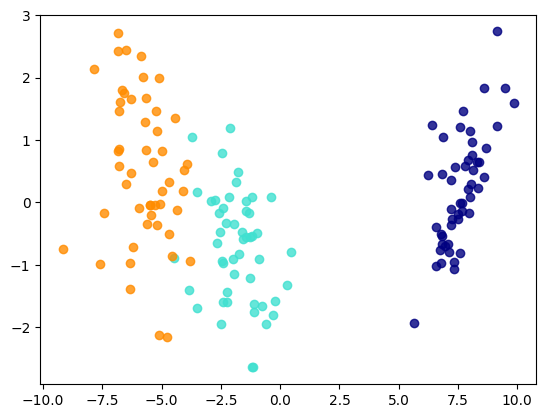

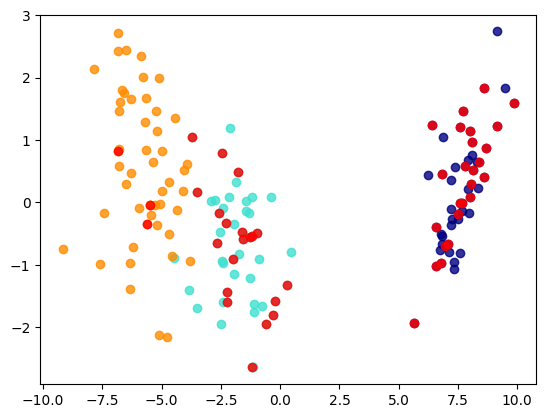

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit(X, y).transform(X)

#print(X_lda)


target_names = iris.target_names

colors = ["navy", "turquoise", "darkorange"]
lw = 2

plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter( X_lda[y == i, 0], X_lda[y == i, 1], alpha=0.8, color=color, label=target_name)
    
plt.show()


plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter( X_lda[y == i, 0], X_lda[y == i, 1], alpha=0.8, color=color, label=target_name)
    
plt.scatter( X_lda[svmclf.support_, 0], X_lda[svmclf.support_, 1], alpha=0.8, color='red', label=target_name)
    
plt.show()

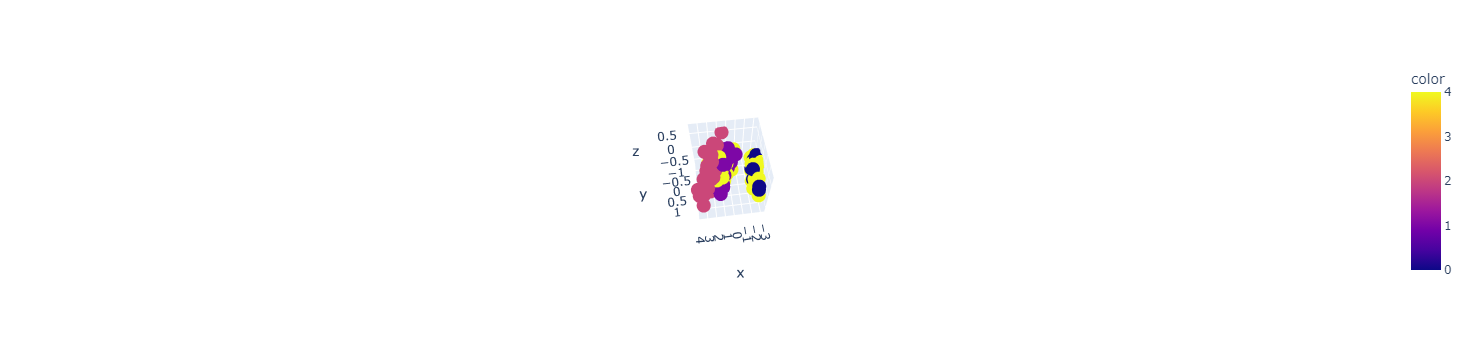

<Figure size 1000x1000 with 0 Axes>

In [23]:
import plotly.express as px
import plotly.offline as pyo
# Set notebook mode to work in offline
pyo.init_notebook_mode()

#lda = LinearDiscriminantAnalysis(n_components=3)
#X_lda = lda.fit(X, y).transform(X)

from sklearn.decomposition import PCA
pca = PCA(n_components = 3).fit(iris.data)
irispca = pca.transform(iris.data)

plt.figure(figsize=(10, 10))

colors = iris.target
colors[svmclf.support_] = 4

fig = px.scatter_3d(x=irispca[:,0], y=irispca[:,1], z=irispca[:,2],color=colors)
#fig = px.scatter_3d(x=irispca[svmclf.support_,0], y=irispca[svmclf.support_,1], z=irispca[svmclf.support_,2],color=['red' for i in range(len(svmclf.support_))])

fig.show()

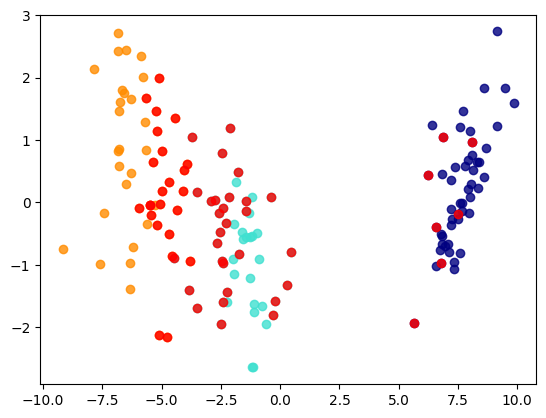

In [24]:
iris = sklearn.datasets.load_iris()

X = iris.data
y = iris.target

svmclf = svm.SVC()
svmclf.fit(X, y)


lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit(X, y).transform(X)

target_names = iris.target_names

colors = ["navy", "turquoise", "darkorange"]
lw = 2

plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter( X_lda[y == i, 0], X_lda[y == i, 1], alpha=0.8, color=color, label=target_name)
    
plt.scatter( X_lda[svmclf.support_, 0], X_lda[svmclf.support_, 1], alpha=0.8, color='red', label=target_name)
    
plt.show()

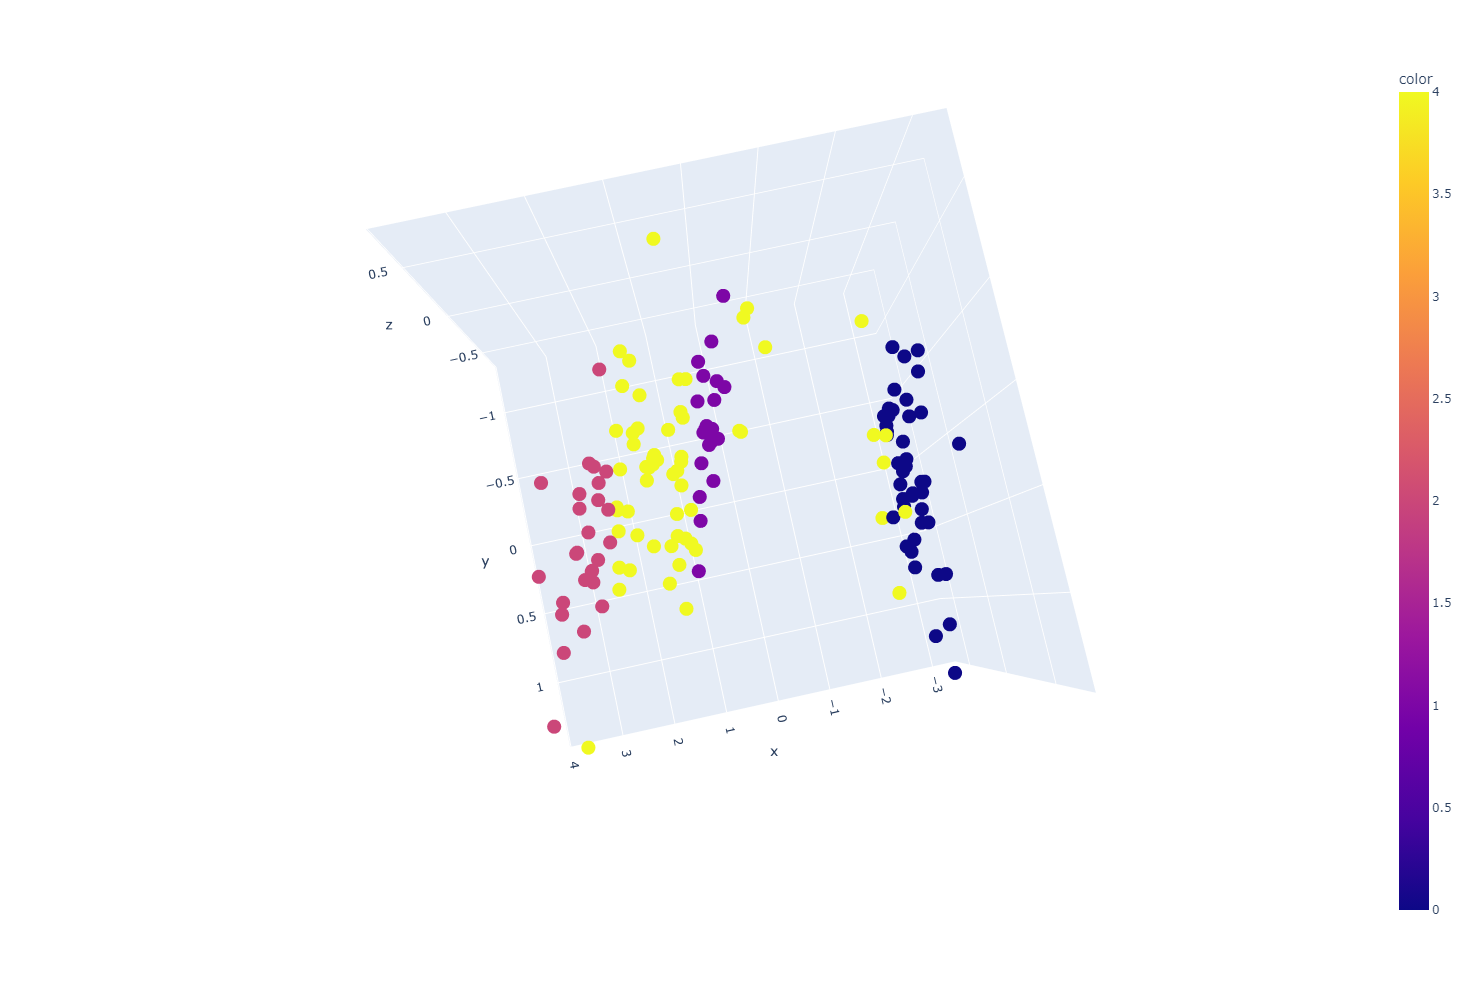

In [25]:

from sklearn.decomposition import PCA
pca = PCA(n_components = 3).fit(iris.data)
irispca = pca.transform(iris.data)

colors = iris.target
colors[svmclf.support_] = 4

fig = px.scatter_3d(x=irispca[:,0], y=irispca[:,1], z=irispca[:,2],color=colors)
#fig = px.scatter_3d(x=irispca[svmclf.support_,0], y=irispca[svmclf.support_,1], z=irispca[svmclf.support_,2],color=['red' for i in range(len(svmclf.support_))])

fig.update_layout(
    autosize=False,
    width=1000,
    height=1000)
    
fig.show()

---
https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py